# Performance Prediction: Version 2.0

## Setup

In [57]:
# libraries to deal with data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# libraries for machine learning
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# libraries to save/load models
import os
import joblib

## Loading Dataset

In [58]:
df_full = pd.read_csv("../data/performance_adjusted_v2.csv", delimiter=",")
df_full.head()

,employee_id,Job_Title,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,...,mental_mean,energy_mean,group,department,seniority,job_title,wellness_index,prod_adj,performance_score_adjusted,rating_label_adjusted
0,c4c45a01-39e8-4561-b936-fcf185b49920,Consultant (Cloud & Infra),Bachelor's,3,3733.33,36.0,32,0,3,50,...,5.808951,6.020228,pregnant,Cloud & Infra,Mid,Consultant (Cloud & Infra),5.554080,3.725815,3.852323,Advanced
1,51b2928a-4091-4430-97a6-50e6fea44476,Senior Consultant (Cybersecurity),Master's,2,6550.00,13.5,22,0,86,26,...,6.380318,5.563556,pregnant,Cybersecurity,Senior,Senior Consultant (Cybersecurity),5.344696,2.643529,2.448237,Developing
2,01229a5b-b84d-4192-8dd3-429f7e705ba1,Junior Consultant (Cybersecurity),High School,3,2833.33,28.7,24,0,9,29,...,5.501952,6.637719,pregnant,Cybersecurity,Junior,Junior Consultant (Cybersecurity),5.662399,2.899429,2.780224,Proficient
3,a04f499a-83c0-49bd-b0d9-3c8783d5fad3,Junior Consultant (Cloud & Infra),High School,2,2350.00,23.3,22,0,5,17,...,5.243579,6.571510,pregnant,Cloud & Infra,Junior,Junior Consultant (Cloud & Infra),5.236954,3.141659,3.094477,Proficient
4,c791ec00-e86c-4e0a-b500-f75ae927521f,Consultant (Digital Transformation),Bachelor's,3,3191.67,23.9,26,0,67,51,...,5.610044,6.196581,pregnant,Digital Transformation,Mid,Consultant (Digital Transformation),5.646257,2.896476,2.776393,Proficient


## Exploratory Data Analysis: Feature Selection

In [59]:
df_full.describe()

,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,digital_score,...,wellness_score,productivity_index,composite_score,capacity_mean,physical_mean,mental_mean,energy_mean,wellness_index,prod_adj,performance_score_adjusted
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.0,1500.000000,1500.000000,...,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,3.072000,4597.766673,33.458000,31.847333,57.121333,13.968667,48.398000,5.0,58.670667,2.936218,...,3.370942,3.080455,7.206753,0.620000,5.734938,6.132355,5.925855,5.931049,3.080455,3.015076
std,0.623224,1583.059183,9.748469,7.383611,131.986864,26.676496,19.974223,0.0,5.050334,0.799089,...,0.103677,0.547648,0.835113,0.048181,0.816603,0.407356,0.509116,0.327519,0.508598,0.659822
min,2.000000,2333.330000,10.200000,15.000000,0.000000,0.000000,0.000000,5.0,47.000000,1.000000,...,2.876923,1.506328,4.240000,0.477257,2.661201,4.721307,4.768376,4.396433,1.527212,1.000000
25%,3.000000,3358.330000,26.600000,26.000000,0.000000,0.000000,33.000000,5.0,55.000000,2.336013,...,3.306766,2.696774,6.590000,0.591397,5.195696,5.826526,5.543234,5.712448,2.729097,2.559247
50%,3.000000,4258.330000,33.800000,31.000000,0.000000,0.000000,48.000000,5.0,60.000000,2.918037,...,3.398174,3.099556,7.300000,0.616426,6.021597,6.124758,6.039316,6.018893,3.085233,3.021274
75%,3.000000,5650.000000,40.100000,37.000000,4.250000,9.000000,62.000000,5.0,61.000000,3.461478,...,3.447797,3.472677,7.920000,0.629826,6.374738,6.491922,6.200467,6.203213,3.444203,3.486978
max,4.000000,9116.670000,62.100000,50.000000,861.000000,93.000000,100.000000,5.0,69.000000,5.000000,...,3.546686,4.419878,8.480000,0.764477,6.969683,7.074300,6.943567,6.429382,4.610456,5.000000


In [60]:
# get all column names
all_cols = df_full.columns.tolist()
all_cols

['employee_id',
 'Job_Title',
 'Education_Level',
 'Performance_Score',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Sick_Days',
 'Remote_Work_Frequency',
 'Team_Size',
 'Training_Hours',
 'digital_score',
 'hard_score',
 'wellness_score',
 'productivity_index',
 'composite_score',
 'rating_label',
 'capacity_mean',
 'physical_mean',
 'mental_mean',
 'energy_mean',
 'group',
 'department',
 'seniority',
 'job_title',
 'wellness_index',
 'prod_adj',
 'performance_score_adjusted',
 'rating_label_adjusted']

In [61]:
# check NaN or null values
df_full.isna().sum()

employee_id                   0
Job_Title                     0
Education_Level               0
Performance_Score             0
Monthly_Salary                0
Work_Hours_Per_Week           0
Projects_Handled              0
Overtime_Hours                0
Sick_Days                     0
Remote_Work_Frequency         0
Team_Size                     0
Training_Hours                0
digital_score                 0
hard_score                    0
wellness_score                0
productivity_index            0
composite_score               0
rating_label                  0
capacity_mean                 0
physical_mean                 0
mental_mean                   0
energy_mean                   0
group                         0
department                    0
seniority                     0
job_title                     0
wellness_index                0
prod_adj                      0
performance_score_adjusted    0
rating_label_adjusted         0
dtype: int64

In [62]:
# check data types
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 1500 non-null   object 
 1   Job_Title                   1500 non-null   object 
 2   Education_Level             1500 non-null   object 
 3   Performance_Score           1500 non-null   int64  
 4   Monthly_Salary              1500 non-null   float64
 5   Work_Hours_Per_Week         1500 non-null   float64
 6   Projects_Handled            1500 non-null   int64  
 7   Overtime_Hours              1500 non-null   int64  
 8   Sick_Days                   1500 non-null   int64  
 9   Remote_Work_Frequency       1500 non-null   int64  
 10  Team_Size                   1500 non-null   int64  
 11  Training_Hours              1500 non-null   int64  
 12  digital_score               1500 non-null   float64
 13  hard_score                  1500 

In [63]:
# get column names with object datatype
object_cols = [col for col in all_cols if df_full[col].dtype == "object"]

# check cardinality (number of unique values in each column)
cardinality = list(map(lambda col: df_full[col].nunique(), object_cols))
d = dict(zip(object_cols, cardinality))
sorted(d.items(), key=lambda x: x[1])

[('Education_Level', 3),
 ('rating_label', 3),
 ('group', 3),
 ('seniority', 4),
 ('department', 5),
 ('rating_label_adjusted', 5),
 ('Job_Title', 20),
 ('job_title', 20),
 ('employee_id', 1500)]

The following columns are excluded from the model:

- **employee_id**: Unique identifier with no predictive value
- **group**: Demographic group (pregnant, non_pregnant_f, male) — excluded to prevent bias; used only in the post-hoc fairness analysis at the end of this notebook
- **department**: Redundant with `Job_Title`, which already encodes the specialisation
- **job_title**: Duplicate of `Job_Title` (lowercase version); one is sufficient
- **seniority**: Encoded implicitly within `Job_Title` (Junior / Consultant / Senior / Managing)
- **rating_label**: Original categorical performance label — superseded by the adjusted version
- **rating_label_adjusted**: String label derived from `performance_score_adjusted`; would introduce leakage since it is the categorical encoding of the target
- **Performance_Score**: Original integer score — replaced by `performance_score_adjusted` as target
- **prod_adj**: Intermediate computation used to derive `performance_score_adjusted`; including it would be a form of data leakage

In [64]:
cols_to_drop = [
    "employee_id", "group", "department", "job_title", "seniority",
    "rating_label", "rating_label_adjusted", "Performance_Score", "prod_adj"
]

# Keep group separately for bias analysis at the end
df_groups = df_full[["employee_id", "group"]].copy()

df = df_full.drop(columns=cols_to_drop)
df.head()

,Job_Title,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,...,hard_score,wellness_score,productivity_index,composite_score,capacity_mean,physical_mean,mental_mean,energy_mean,wellness_index,performance_score_adjusted
0,Consultant (Cloud & Infra),Bachelor's,3733.33,36.0,32,0,3,50,5,60,...,3.613905,3.269041,3.354957,7.02,0.553077,4.833060,5.808951,6.020228,5.554080,3.852323
1,Senior Consultant (Cybersecurity),Master's,6550.00,13.5,22,0,86,26,5,55,...,1.657650,3.151496,2.066682,5.73,0.700882,4.090214,6.380318,5.563556,5.344696,2.448237
2,Junior Consultant (Cybersecurity),High School,2833.33,28.7,24,0,9,29,5,66,...,2.653868,3.324756,2.635134,6.73,0.572610,4.847527,5.501952,6.637719,5.662399,2.780224
3,Junior Consultant (Cloud & Infra),High School,2350.00,23.3,22,0,5,17,5,65,...,2.641127,3.162165,2.458817,5.85,0.517023,3.895773,5.243579,6.571510,5.236954,3.094477
4,Consultant (Digital Transformation),Bachelor's,3191.67,23.9,26,0,67,51,5,61,...,2.078536,3.318262,2.616301,7.35,0.707916,5.132147,5.610044,6.196581,5.646257,2.776393


## Exploratory Data Analysis: Checking Performance Score (Adjusted)

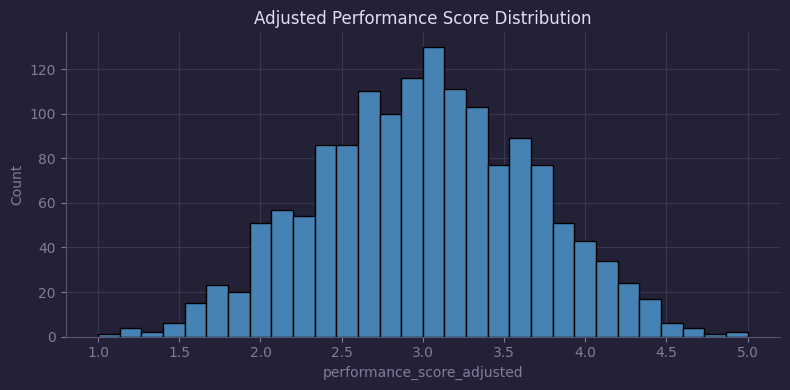

count    1500.000000
mean        3.015076
std         0.659822
min         1.000000
25%         2.559247
50%         3.021274
75%         3.486978
max         5.000000
Name: performance_score_adjusted, dtype: float64


In [65]:
# distribution of the adjusted performance score (continuous)
plt.figure(figsize=(8, 4))
df["performance_score_adjusted"].hist(bins=30, color="steelblue", edgecolor="black")
plt.xlabel("performance_score_adjusted")
plt.ylabel("Count")
plt.title("Adjusted Performance Score Distribution")
plt.tight_layout()
plt.style.use('./rose-pine-moon.mplstyle')

plt.show()


print(df["performance_score_adjusted"].describe())

The target variable `performance_score_adjusted` is continuous. For classification we bin it into the same five ordered categories used by `rating_label_adjusted` (Needs Improvement, Developing, Proficient, Advanced, Expert).

In [66]:
# Map performance_score_adjusted → ordinal class (1–5) matching rating_label_adjusted logic
def score_to_class(s):
    if s < 1.5:
        return 1   # Needs Improvement
    elif s < 2.5:
        return 2   # Developing
    elif s < 3.5:
        return 3   # Proficient
    elif s < 4.5:
        return 4   # Advanced
    else:
        return 5   # Expert

df["perf_class"] = df["performance_score_adjusted"].apply(score_to_class)

# Verify alignment with rating_label_adjusted before dropping it
label_map = {1: "Needs Improvement", 2: "Developing", 3: "Proficient", 4: "Advanced", 5: "Expert"}
print("Class distribution:")
print(df["perf_class"].value_counts().sort_index().rename(label_map))

Class distribution:
perf_class
Needs Improvement     12
Developing           326
Proficient           792
Advanced             360
Expert                10
Name: count, dtype: int64


## Exploratory Data Analysis: Checking Monthly Salary w.r.t Job Title

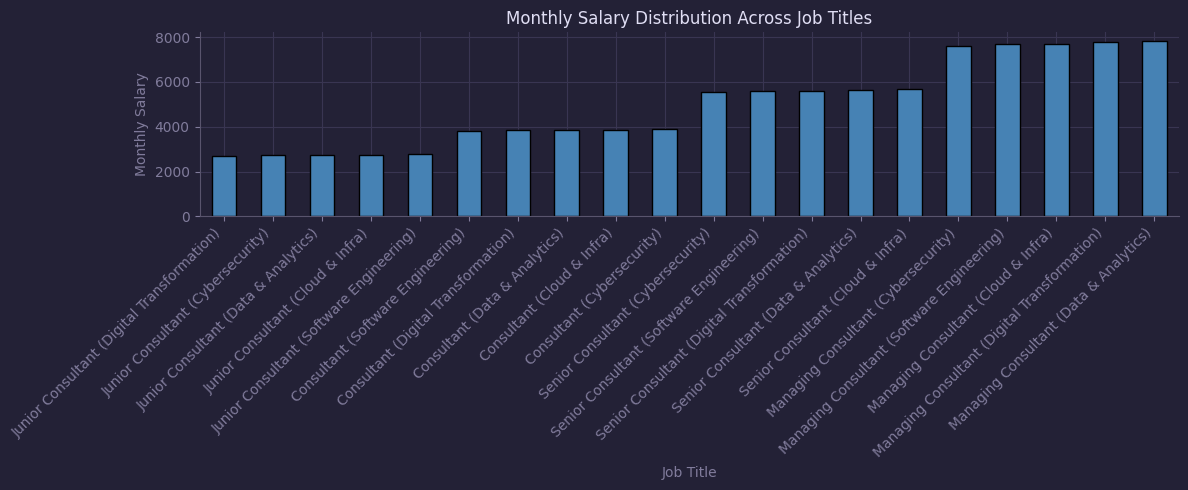

In [67]:
avg_salary_for_jobs = df.groupby("Job_Title")["Monthly_Salary"].mean().sort_values()

avg_salary_for_jobs.plot(kind="bar", color="steelblue", edgecolor="black", figsize=(12, 5))
plt.xlabel("Job Title")
plt.ylabel("Monthly Salary")
plt.title("Monthly Salary Distribution Across Job Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis: Checking Monthly Salary w.r.t Education Level

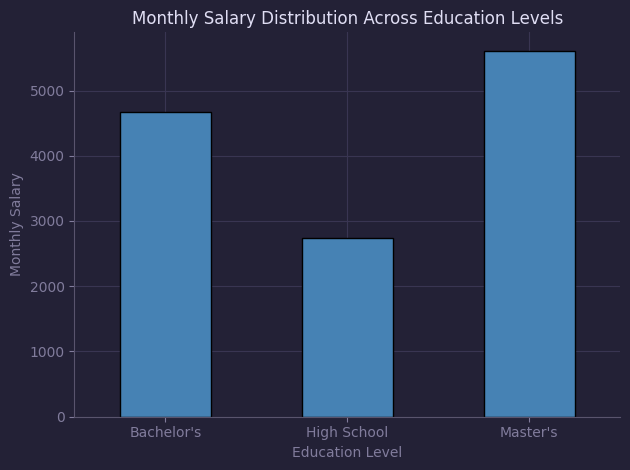

In [68]:
avg_salary_for_edu = df.groupby("Education_Level")["Monthly_Salary"].mean()

avg_salary_for_edu.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Education Level")
plt.ylabel("Monthly Salary")
plt.title("Monthly Salary Distribution Across Education Levels")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis: Checking Feature-Target Relationship

In [69]:
# Separate numeric and categorical feature columns (exclude targets and class label)
exclude = {"perf_class", "performance_score_adjusted"}
numeric_cols = [c for c in df.select_dtypes(include=["number"]).columns if c not in exclude]
categorical_cols = [c for c in df.select_dtypes(include=["object"]).columns]

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

Numeric features: ['Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'digital_score', 'hard_score', 'wellness_score', 'productivity_index', 'composite_score', 'capacity_mean', 'physical_mean', 'mental_mean', 'energy_mean', 'wellness_index']
Categorical features: ['Job_Title', 'Education_Level']


In [70]:
# Correlations with the continuous target
df[numeric_cols + ["performance_score_adjusted"]].corr()["performance_score_adjusted"].sort_values(ascending=False)

performance_score_adjusted    1.000000
digital_score                 0.826699
Remote_Work_Frequency         0.826493
productivity_index            0.816371
hard_score                    0.724713
Work_Hours_Per_Week           0.720369
Projects_Handled              0.670475
composite_score               0.654856
Overtime_Hours                0.547742
Monthly_Salary                0.360723
mental_mean                   0.192066
physical_mean                -0.079369
wellness_score               -0.134730
wellness_index               -0.190914
Sick_Days                    -0.246333
energy_mean                  -0.394821
Training_Hours               -0.396371
capacity_mean                -0.434073
Team_Size                          NaN
Name: performance_score_adjusted, dtype: float64

In [71]:
# ANOVA for categorical columns
for col in categorical_cols:
    groups = [df[df[col] == val]["performance_score_adjusted"] for val in df[col].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\n{col}:")
    print(f"  ANOVA p-value: {p_value:.6f}")
    if p_value < 0.05:
        print(f"  - Statistically significant at 95% confidence")
        print(df.groupby(col)["performance_score_adjusted"].mean())
    else:
        print(f"  - Not statistically significant at 95% confidence")


Job_Title:
  ANOVA p-value: 0.000000
  - Statistically significant at 95% confidence
Job_Title
Consultant (Cloud & Infra)                      2.973356
Consultant (Cybersecurity)                      2.947424
Consultant (Data & Analytics)                   2.967745
Consultant (Digital Transformation)             2.886141
Consultant (Software Engineering)               3.015464
Junior Consultant (Cloud & Infra)               2.585955
Junior Consultant (Cybersecurity)               2.653450
Junior Consultant (Data & Analytics)            2.657114
Junior Consultant (Digital Transformation)      2.603292
Junior Consultant (Software Engineering)        2.632212
Managing Consultant (Cloud & Infra)             3.762348
Managing Consultant (Cybersecurity)             3.652203
Managing Consultant (Data & Analytics)          3.551520
Managing Consultant (Digital Transformation)    3.428253
Managing Consultant (Software Engineering)      3.612009
Senior Consultant (Cloud & Infra)               3

## Data Preprocessing: Data Splitting

In [72]:
target_col = "perf_class"
features_col = [c for c in df.columns if c not in {"perf_class", "performance_score_adjusted"}]

X = df[features_col]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1200, 20), Test: (300, 20)


## Data Preprocessing: Encoding Categorical Variables as Numeric

In [73]:
print("Education_Level unique:", X_train["Education_Level"].unique())

Education_Level unique: ['High School' "Bachelor's" "Master's"]


In [74]:
# Ordinal encoding for Education_Level (no PhD in this dataset)
ordinal_cols = ["Education_Level"]
# Note the straight apostrophe (') instead of curly (’)
education_order = [["High School", "Bachelor's", "Master's"]]

In [75]:
print("Job_Title unique:", X_train["Job_Title"].unique())

Job_Title unique: ['Junior Consultant (Digital Transformation)' 'Consultant (Cloud & Infra)'
 'Consultant (Digital Transformation)' 'Consultant (Data & Analytics)'
 'Consultant (Software Engineering)' 'Consultant (Cybersecurity)'
 'Senior Consultant (Cybersecurity)'
 'Junior Consultant (Data & Analytics)'
 'Senior Consultant (Software Engineering)'
 'Junior Consultant (Cloud & Infra)'
 'Senior Consultant (Data & Analytics)'
 'Senior Consultant (Cloud & Infra)'
 'Senior Consultant (Digital Transformation)'
 'Managing Consultant (Cloud & Infra)'
 'Managing Consultant (Digital Transformation)'
 'Junior Consultant (Software Engineering)'
 'Managing Consultant (Software Engineering)'
 'Junior Consultant (Cybersecurity)' 'Managing Consultant (Cybersecurity)'
 'Managing Consultant (Data & Analytics)']


In [76]:
# One-hot encoding for Job_Title (no natural order)
onehot_cols = ["Job_Title"]

In [77]:
# LabelEncoder for target (maps 1–5 → 0–4)
label_encoder = LabelEncoder()
label_y_train = label_encoder.fit_transform(y_train)
label_y_test  = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: [1 2 3 4 5]


## Data Preprocessing: Creating a Column Transformer

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",     StandardScaler(),                             [c for c in numeric_cols if c in features_col]),
        ("ordinal", OrdinalEncoder(categories=education_order),  ordinal_cols),
        ("onehot",  OneHotEncoder(drop="first", sparse_output=False), onehot_cols),
    ],
    remainder="passthrough"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

## Model: Selection Rationale

Five models are selected for performance prediction:

1. **Logistic Regression**: Baseline linear model with interpretable coefficients.
2. **Ridge Classifier**: L2-regularised linear classifier; more robust to multicollinearity.
3. **Random Forest Classifier**: Ensemble of trees; handles feature interactions and provides feature importance.
4. **Gradient Boosting Classifier**: Sequential boosting; captures complex non-linear relationships.
5. **XGBoost Classifier**: Optimised gradient boosting with regularisation; well-suited for tabular multiclass tasks.

In [79]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Ridge Classifier":    RidgeClassifier(alpha=1.0, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(
                               n_estimators=100, random_state=42, n_jobs=-1,
                               objective="multi:softprob",
                               num_class=5,
                               eval_metric="mlogloss"
                           ),
}

## Model: Cross-Validation

In [80]:
cv_results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model",        model)
    ])
    cv_scores = cross_val_score(pipeline, X_train, label_y_train, cv=5, scoring="accuracy", n_jobs=-1)
    cv_results[name] = {
        "mean_cv_score": cv_scores.mean(),
        "std_cv_score":  cv_scores.std(),
        "cv_scores":     cv_scores,
    }
    print(f"{name}: mean accuracy = {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Logistic Regression: mean accuracy = 0.9450 (+/- 0.0359)
Ridge Classifier: mean accuracy = 0.7767 (+/- 0.0523)
Random Forest: mean accuracy = 0.9142 (+/- 0.0233)
Gradient Boosting: mean accuracy = 0.9167 (+/- 0.0279)
XGBoost: mean accuracy = 0.9242 (+/- 0.0359)


## Model: Training & Evaluation

In [81]:
cv_comparison = pd.DataFrame({
    name: {
        "Mean CV Accuracy": cv_results[name]["mean_cv_score"],
        "Std CV Accuracy":  cv_results[name]["std_cv_score"],
    }
    for name in cv_results
}).T

cv_comparison

,Mean CV Accuracy,Std CV Accuracy
Logistic Regression,0.945000,0.017951
Ridge Classifier,0.776667,0.026167
Random Forest,0.914167,0.011667
Gradient Boosting,0.916667,0.013944
XGBoost,0.924167,0.017951


In [82]:
best_model_name = cv_comparison.sort_values("Mean CV Accuracy", ascending=False).index[0]
best_model      = models[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"Mean CV accuracy (5-fold): {cv_comparison.loc[best_model_name, 'Mean CV Accuracy']:.4f}")

Selected model: Logistic Regression
Mean CV accuracy (5-fold): 0.9450


In [83]:
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        best_model)
])

best_pipeline.fit(X_train, label_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

Accuracy: 0.9533

Classification Report:
                   precision    recall  f1-score   support

Needs Improvement       0.00      0.00      0.00         3
       Developing       0.92      0.94      0.93        65
       Proficient       0.96      0.97      0.97       158
         Advanced       0.96      0.97      0.97        72
           Expert       1.00      0.50      0.67         2

         accuracy                           0.95       300
        macro avg       0.77      0.68      0.71       300
     weighted avg       0.94      0.95      0.95       300



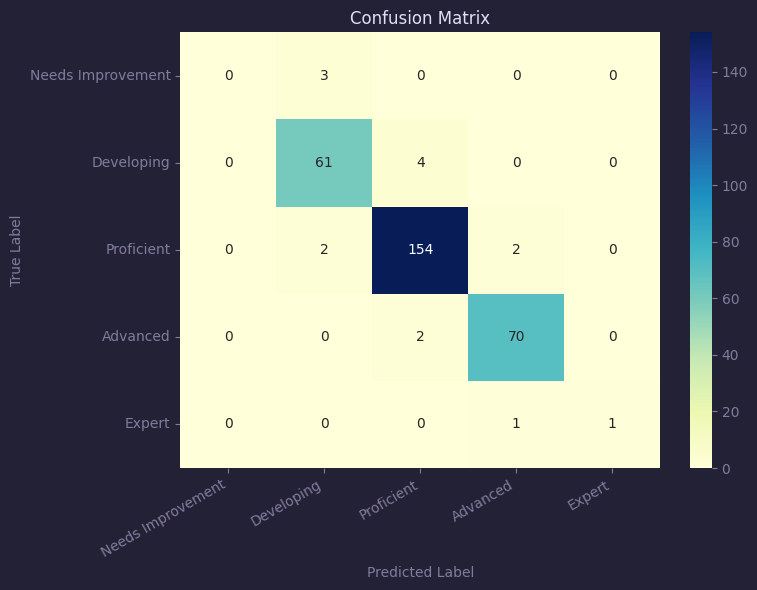

In [84]:
class_names = ["Needs Improvement", "Developing", "Proficient", "Advanced", "Expert"]

label_y_test_pred_encoded = best_pipeline.predict(X_test)
y_test_pred = label_encoder.inverse_transform(label_y_test_pred_encoded)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=30, ha="right")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Saving Model & Preprocessing Objects

In [85]:
os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/performance_prediction_model.pkl")
print("Performance model saved.")

Performance model saved.


In [86]:
os.makedirs("../preprocessors", exist_ok=True)
joblib.dump(label_encoder, "../preprocessors/label_encoder.pkl")

os.makedirs("../data/processed", exist_ok=True)
feature_info = {
    "categorical_cols": categorical_cols,
    "numeric_cols":     numeric_cols,
    "onehot_cols":      onehot_cols,
    "ordinal_cols":     ordinal_cols,
    "all_features":     features_col,
}
joblib.dump(feature_info, "../data/processed/performance_feature_info.pkl")
print("Preprocessing objects saved.")

Preprocessing objects saved.


## Fairness Analysis: Predicted Performance Across Groups

This section evaluates whether the trained model produces systematically different predictions for the three demographic groups (**pregnant**, **non_pregnant_f**, **male**).

The group column was deliberately excluded from model training to prevent it from influencing predictions. Here we re-attach it to the **full dataset** (not just the test set) and compare:

1. **Mean `performance_score_adjusted`** (ground-truth target, continuous)
2. **Mean model-predicted class** (0–4, mapped back to 1–5)
3. **Mean `Monthly_Salary`** (money variable from the dataset)

A fair model should show no statistically meaningful difference in average predicted scores across groups when controlling for the same input features.

In [87]:
# ── Re-attach group to the full feature set (no group in X) ──────────────────
df_bias = df_full.copy()

# Produce predictions for all 1500 rows using the same features as training
X_all = df_full.drop(columns=cols_to_drop + ["performance_score_adjusted"])
X_all = X_all[[c for c in features_col]]   # ensure column order matches training

pred_encoded_all = best_pipeline.predict(X_all)
pred_class_all   = label_encoder.inverse_transform(pred_encoded_all)   # back to 1–5

df_bias["predicted_perf_class"] = pred_class_all
df_bias["predicted_perf_score"] = pred_class_all.astype(float)

print(df_bias[["group", "predicted_perf_class"]].value_counts().sort_index())

group           predicted_perf_class
male            2                        91
                3                       291
                4                       118
non_pregnant_f  2                       115
                3                       266
                4                       118
                5                         1
pregnant        1                         2
                2                       125
                3                       245
                4                       126
                5                         2
Name: count, dtype: int64


In [88]:
# ── 1. Mean actual vs predicted performance score by group ───────────────────
group_perf = df_bias.groupby("group").agg(
    n                        = ("group", "count"),
    mean_actual_perf_score   = ("performance_score_adjusted", "mean"),
    mean_predicted_perf_score= ("predicted_perf_score",       "mean"),
    mean_monthly_salary      = ("Monthly_Salary",             "mean"),
).round(4)

print("Performance & Salary by Group:")
print(group_perf.to_string())

Performance & Salary by Group:
                  n  mean_actual_perf_score  mean_predicted_perf_score  mean_monthly_salary
group                                                                                      
male            500                  3.0357                      3.054            4649.0167
non_pregnant_f  500                  2.9935                      3.010            4632.2333
pregnant        500                  3.0160                      3.002            4512.0500


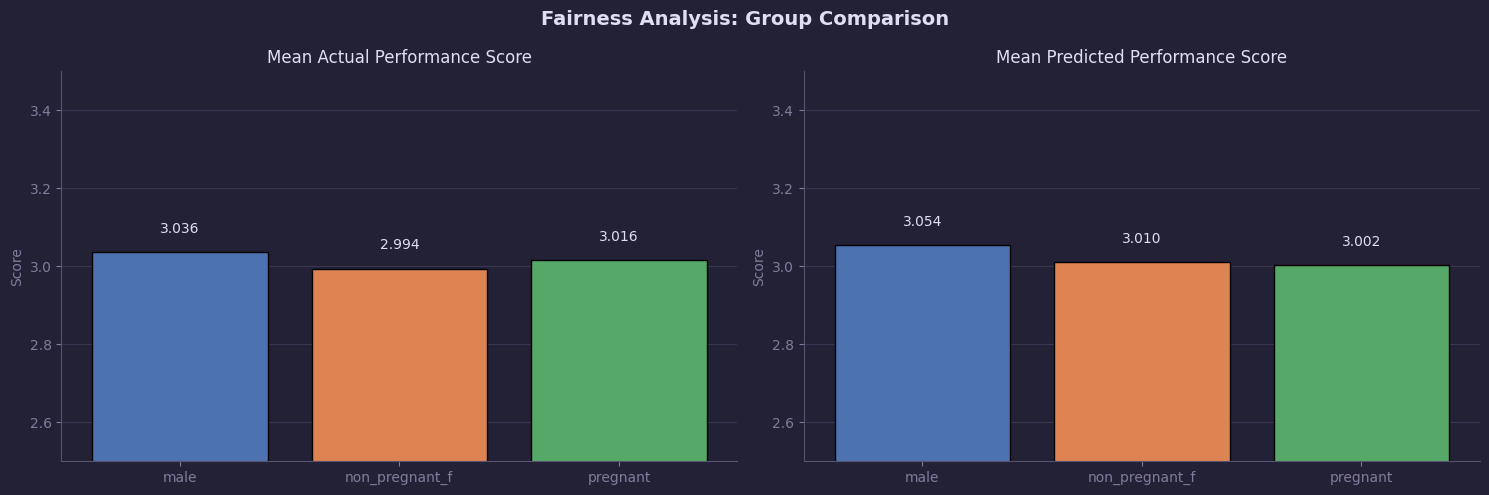

In [89]:
# ── 2. Visualise actual vs predicted performance by group ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

groups     = group_perf.index.tolist()
bar_colors = ["#4C72B0", "#DD8452", "#55A868"]

# Actual performance score
axes[0].bar(groups, group_perf["mean_actual_perf_score"], color=bar_colors, edgecolor="black")
axes[0].set_title("Mean Actual Performance Score")
axes[0].set_ylabel("Score")
axes[0].set_ylim(2.5, 3.5)
for i, v in enumerate(group_perf["mean_actual_perf_score"]):
    axes[0].text(i, v + 0.05, f"{v:.3f}", ha="center", fontsize=10)

# Predicted performance score
axes[1].bar(groups, group_perf["mean_predicted_perf_score"], color=bar_colors, edgecolor="black")
axes[1].set_title("Mean Predicted Performance Score")
axes[1].set_ylabel("Score")
axes[1].set_ylim(2.5, 3.5)
for i, v in enumerate(group_perf["mean_predicted_perf_score"]):
    axes[1].text(i, v + 0.05, f"{v:.3f}", ha="center", fontsize=10)



plt.suptitle("Fairness Analysis: Group Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [90]:
# ── 3. Statistical test: one-way ANOVA across groups ────────────────────────
from scipy.stats import f_oneway

groups_data_pred   = [df_bias[df_bias["group"] == g]["predicted_perf_score"].values   for g in groups]
groups_data_actual = [df_bias[df_bias["group"] == g]["performance_score_adjusted"].values for g in groups]
groups_data_salary = [df_bias[df_bias["group"] == g]["Monthly_Salary"].values          for g in groups]

f_pred,   p_pred   = f_oneway(*groups_data_pred)
f_actual, p_actual = f_oneway(*groups_data_actual)
f_sal,    p_sal    = f_oneway(*groups_data_salary)

print("ANOVA Results (H0: all group means are equal):")
print(f"  Predicted Performance Score : F={f_pred:.4f},  p={p_pred:.4f}  {'→ significant' if p_pred<0.05 else '→ not significant'}")
print(f"  Actual Performance Score    : F={f_actual:.4f}, p={p_actual:.4f}  {'→ significant' if p_actual<0.05 else '→ not significant'}")
print(f"  Monthly Salary              : F={f_sal:.4f},  p={p_sal:.4f}  {'→ significant' if p_sal<0.05 else '→ not significant'}")

ANOVA Results (H0: all group means are equal):
  Predicted Performance Score : F=0.8248,  p=0.4385  → not significant
  Actual Performance Score    : F=0.5112, p=0.5999  → not significant
  Monthly Salary              : F=1.1136,  p=0.3286  → not significant


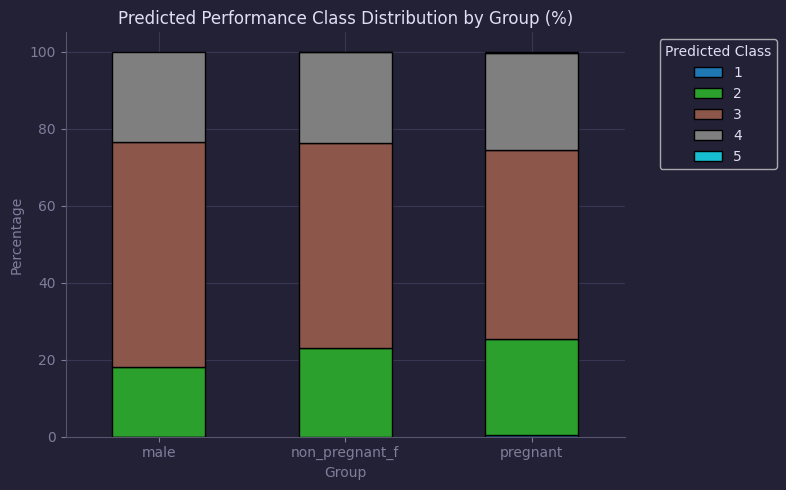

In [91]:
# ── 4. Distribution of predicted classes per group (stacked bar) ─────────────
pred_dist = (
    df_bias.groupby(["group", "predicted_perf_class"])
    .size()
    .unstack(fill_value=0)
)
pred_dist_pct = pred_dist.div(pred_dist.sum(axis=1), axis=0) * 100

pred_dist_pct.plot(kind="bar", stacked=True, colormap="tab10", edgecolor="black", figsize=(8, 5))
plt.title("Predicted Performance Class Distribution by Group (%)")
plt.ylabel("Percentage")
plt.xlabel("Group")
plt.xticks(rotation=0)
plt.legend(title="Predicted Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [92]:
# ============================================================
# BIAS AUDIT – V2
# ============================================================
import pandas as pd
from scipy import stats

df_full = pd.read_csv("../data/performance_adjusted_v2.csv")

groups_list = ["male", "non_pregnant_f", "pregnant"]

bias_cols = {
    "Performance_Score (original)":  "Performance_Score",
    "Performance_Score (adjusted)":  "performance_score_adjusted",
    "Monthly_Salary":                "Monthly_Salary",
    "productivity_index":            "productivity_index",
    "wellness_index":                "wellness_index",
    "composite_score":               "composite_score",
}

print("=== MEDIAS POR GRUPO ===")
agg = df_full.groupby("group")[list(bias_cols.values())].mean().round(4)
print(agg.to_string())

print("\n=== ANOVA POR VARIABLE (H0: todas las medias son iguales) ===")
for label, col in bias_cols.items():
    if col not in df_full.columns:
        print(f"  {label}: columna no encontrada, omitida")
        continue
    arrays = [df_full[df_full["group"] == g][col].dropna().values for g in groups_list]
    f_val, p_val = stats.f_oneway(*arrays)
    sig = "⚠  SIGNIFICATIVO – posible sesgo" if p_val < 0.05 else "✓  no significativo"
    print(f"  {label:<40}: F={f_val:.4f}, p={p_val:.6f}  → {sig}")

=== MEDIAS POR GRUPO ===
                Performance_Score  performance_score_adjusted  Monthly_Salary  productivity_index  wellness_index  composite_score
group                                                                                                                             
male                        3.276                      3.0357       4649.0167              3.2826          6.1204           7.4753
non_pregnant_f              3.216                      2.9935       4632.2333              3.2273          6.0972           7.3579
pregnant                    2.724                      3.0160       4512.0500              2.7315          5.5756           6.7871

=== ANOVA POR VARIABLE (H0: todas las medias son iguales) ===
  Performance_Score (original)            : F=139.9775, p=0.000000  → ⚠  SIGNIFICATIVO – posible sesgo
  Performance_Score (adjusted)            : F=0.5112, p=0.599876  → ✓  no significativo
  Monthly_Salary                          : F=1.1136, p=0.328630  

### Interpretation

- **Actual vs Predicted scores**: compare `mean_actual_perf_score` and `mean_predicted_perf_score` per group. A fair model should show similar gaps (or no gap) across groups.
- **Salary**: any salary difference across groups reflects patterns in the *data*, not in the model (salary was an input feature, not predicted here). Salary disparities in the data are reported as a transparency measure.
- **ANOVA**: a significant p-value (< 0.05) for the predicted score across groups would indicate that the model's output correlates with group membership despite the group column being excluded — signalling potential indirect bias through proxy features.

This notebook was updated by `La Wun Nannda`.

In [93]:
import matplotlib

matplotlib.get_configdir()

'/home/pvtoari/.config/matplotlib'